In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
X=6*np.random.rand(100,1)-3##100 rows and 1 column range from -3 to 3
y=0.5*X**2+1.5*X+2+np.random.randn(100,1)

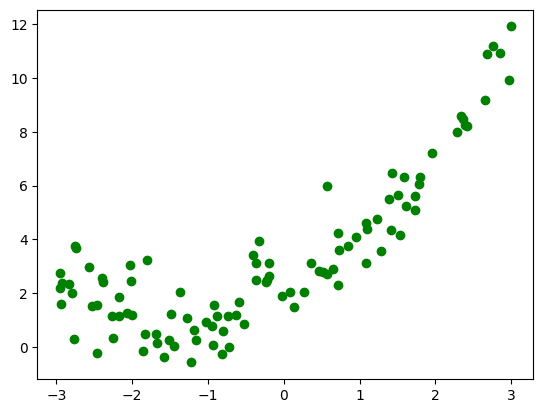

In [5]:
plt.scatter(X,y,color='g')

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
##Implementing simple linear regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [8]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6537804730722836


Text(0, 0.5, 'Y DataSet')

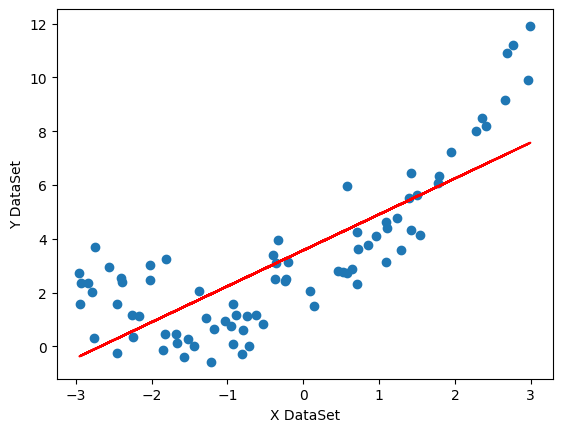

In [11]:
##visualising the model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X DataSet")
plt.ylabel("Y DataSet")

In [13]:
##applying polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)##degreee =2 means x^2 is created
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [15]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9507645632172712


In [16]:
print(regression.coef_)

[[0.         1.48903446 0.52353484]]


In [17]:
print(regression.intercept_)

[2.07524698]


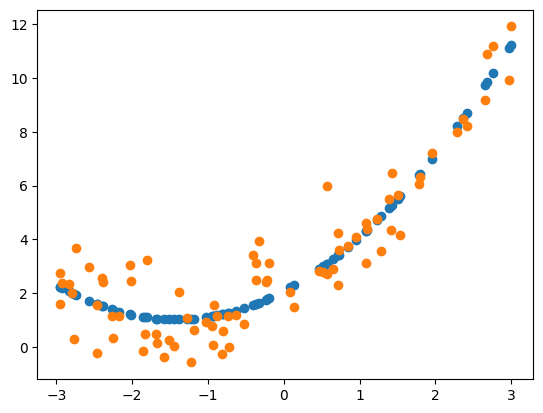

In [19]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [28]:
## if we make degree 3
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=5,include_bias=True)##degreee =2 means x^2 is created
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [29]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9567871167822162


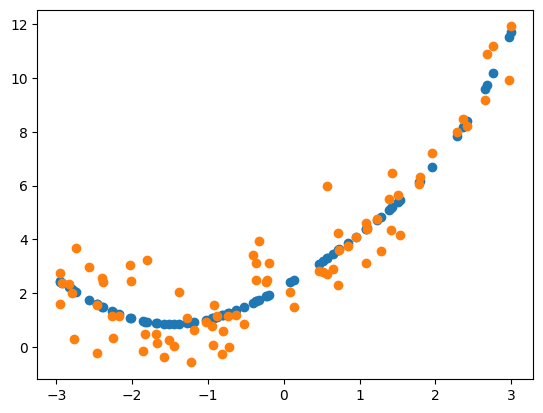

In [30]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [32]:
##prediciton of new data set
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
X_new_poly

array([[   1.        ,   -3.        ,    9.        ,  -27.        ,
          81.        , -243.        ],
       [   1.        ,   -2.96984925,    8.82000455,  -26.19408385,
          77.79248018, -231.03193862],
       [   1.        ,   -2.93969849,    8.64182723,  -25.40436647,
          74.68117781, -219.54014584],
       ...,
       [   1.        ,    2.93969849,    8.64182723,   25.40436647,
          74.68117781,  219.54014584],
       [   1.        ,    2.96984925,    8.82000455,   26.19408385,
          77.79248018,  231.03193862],
       [   1.        ,    3.        ,    9.        ,   27.        ,
          81.        ,  243.        ]], shape=(200, 6))

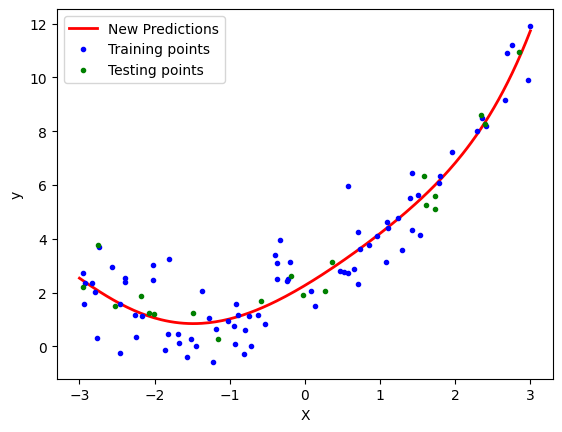

In [34]:
y_new=regression.predict(X_new_poly)
plt.plot(X_new,y_new,'r-',linewidth=2,label='New Predictions')
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()